# Accessing ESA Antarctica Datacube Sea Ice Data

This notebook is a runnable remote-access demo for the ESA Antarctica Datacube. The example uses an ROI close to Palmer Land and the George VI Ice Shelf.

Plot 4 also shows an example of how to combine the sea-ice cube data with the land ice cubes.

## Setup

The constants below define the remote Zarr stores, the example ROI, and the
sampling used for velocity arrows. All following sections use named variables
rather than passing dictionaries around.


In [ ]:
import numpy as np
import geopandas as gpd
import warnings
import xarray as xr
from dask.array.core import PerformanceWarning
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Rectangle
import rioxarray
from rasterio.enums import Resampling

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", message="In a future version of xarray the default value for join.*", category=FutureWarning)
warnings.filterwarnings("ignore", message="Increasing number of chunks.*", category=PerformanceWarning)

ds = xr.open_zarr(
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/sea-ice/sea-ice-cube.zarr",
    group="0",
    chunks={},
)
ds

## Plot 1: CS+AO Sea-Ice Thickness


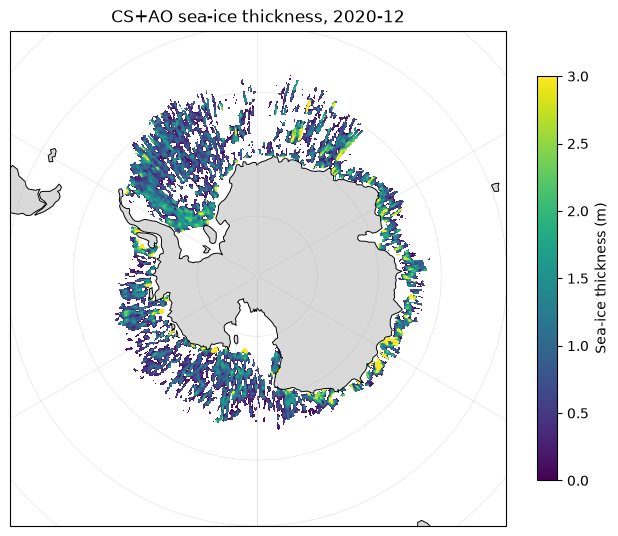

In [48]:
MIN_CONCENTRATION = 15
month = ds["time"].isel(time=-28)
thickness = ds.SIT_ASD_mean.sel(time=month)
concentration = ds.sea_ice_conc.sel(time=month)
thickness = thickness.where(concentration >= MIN_CONCENTRATION)
thickness = thickness.where((thickness >= 0) & (thickness <= 20))

fig = plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

mesh = ax.pcolormesh(
    ds["longitude"],
    ds["latitude"],
    thickness,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=3,
)
fig.colorbar(mesh, ax=ax, shrink=0.75, pad=0.05, label="Sea-ice thickness (m)")
    
ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
ax.coastlines(linewidth=0.7)
ax.gridlines(draw_labels=False, linewidth=0.4, alpha=0.4)
ax.set_title(f"CS+AO sea-ice thickness, {str(month.values)[:7]}")

plt.show()

## Plot 2: Sea Surface Salinity


In [ ]:
subset = ds['sss'].sel(
    time=["2011-02-01", "2016-01-01", "2021-01-01"],
    method="nearest"
)
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

for ax, t in zip(axes, subset.time):
    plot_data = ds['sss'].sel(time=t)
    im = ax.pcolormesh(
        ds["x"],
        ds["y"],
        plot_data,
        shading="auto",
        cmap="viridis"
    )
plt.show()

## Plot 3: Auxiliary Data: Tidal Elevation - ALBATROS

See - `1_Datasets/albatros/access.ipynb` for an example of how to reproject the point data

In [ ]:
gdf = gpd.read_parquet(
    "/Users/dean/code/polar_hackathon/downloaded_data/albatros_example.parquet"
).to_crs(6932)

sss = ds.sss.sel(time="2019-04-01", method="nearest")

fig, ax = plt.subplots(figsize=(12, 10), constrained_layout=True)

image = ax.pcolormesh(
    ds.x, ds.y, sss,
    shading="auto",
    cmap="viridis",
)

gdf.plot(
    column="avg_tidal_elevation_m",
    ax=ax,
    cmap="RdBu_r",
    legend=True,
    zorder=2,
)

limits = ax.get_xlim(), ax.get_ylim()

coastlines = gpd.GeoSeries(
    list(cfeature.COASTLINE.geometries()),
    crs=4326,
).to_crs(6932)

coastlines.plot(ax=ax, color="black", linewidth=0.7, zorder=3)
ax.set_xlim(limits[0])
ax.set_ylim(limits[1])
ax.set_title("SOFRESH and ALBATROS — 2019-04")

fig.colorbar(image, ax=ax, label="Sea-surface salinity")
plt.show()

## Plot 4: Combining Data From Land Ice Cube

This plot combines sea-ice thickness with the boundary of the land-ice GeoZarr composite mask at the nearest available time.


In [ ]:
month = "2019-04-01"
land_ds = xr.open_zarr(
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/land-ice/icemask_composite.zarr",
    group="0",
    chunks={},
)
# select a subset of the data for the given month
land_ds = land_ds.sel(time=month, method="nearest")
ROI_CENTER_XY_M = (-2_000_000.0, 800_000.0)
ROI_HALF_WIDTH_CELLS = 7000
x_index = int(np.abs(land_ds["x"].values - ROI_CENTER_XY_M[0]).argmin())
y_index = int(np.abs(land_ds["y"].values - ROI_CENTER_XY_M[1]).argmin())
x_slice = slice(x_index - ROI_HALF_WIDTH_CELLS, x_index + ROI_HALF_WIDTH_CELLS + 1)
y_slice = slice(y_index - ROI_HALF_WIDTH_CELLS, y_index + ROI_HALF_WIDTH_CELLS + 1)
small = land_ds.isel(x=x_slice, y=y_slice).chunk({"x": -1, "y": -1})
small = small.rio.write_crs(3031)
small

In [ ]:
thickness = (
    ds.SIT_ASD_mean.sel(time=month, method="nearest")
    .rio.set_spatial_dims(x_dim="x", y_dim="y")
    .rio.write_crs(6932)
)
ice_mask = (
    small.icemask_composite
    .rio.set_spatial_dims(x_dim="x", y_dim="y")
    .rio.write_crs(3031)
)
thickness_3031 = thickness.rio.reproject_match(
    ice_mask,
    resampling=Resampling.nearest,
)

fig, ax = plt.subplots(figsize=(10, 8))

thickness_3031.plot(ax=ax, cmap="viridis")
ice_mask.plot.contour(
    ax=ax,
    levels=[0.5],
    colors="red",
    linewidths=1,
)

ax.set_aspect("equal")
plt.show()